In [2]:
# Celda 1 — Instalar dependencias y montar Drive
!pip install shap statsmodels -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import shap
from google.colab import drive
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("Setup completado.")

Mounted at /content/drive
Setup completado.


In [3]:
# Celda 2 — Cargar datos y top-2 modelos
X_train = np.load(DRIVE_PATH + "X_train.npy")
X_val   = np.load(DRIVE_PATH + "X_val.npy")
X_test  = np.load(DRIVE_PATH + "X_test.npy")
y_train = np.load(DRIVE_PATH + "y_train.npy")
y_val   = np.load(DRIVE_PATH + "y_val.npy")
y_test  = np.load(DRIVE_PATH + "y_test.npy")
FEATURES = np.load(DRIVE_PATH + "feature_names.npy").tolist()

top2_nombres = np.load(DRIVE_PATH + "top2_modelos.npy", allow_pickle=True).tolist()
print(f"Top 2 modelos: {top2_nombres}")

# Cargar modelos top-2
top2_objetos = {}
for nombre in top2_nombres:
    safe = nombre.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
    pkl_path = DRIVE_PATH + f"modelo_{safe}.pkl"
    with open(pkl_path, "rb") as f:
        top2_objetos[nombre] = pickle.load(f)
    print(f"  Cargado: {safe}.pkl")

# Cargar tabla comparativa
df_original = pd.read_csv(DRIVE_PATH + "tabla_comparativa_modelos.csv", index_col="Modelo")
print(f"\n{len(df_original)} modelos en tabla comparativa.")

Top 2 modelos: ['Red Neuronal (MLP)', 'XGBoost']
  Cargado: Red_Neuronal_MLP.pkl
  Cargado: XGBoost.pkl

15 modelos en tabla comparativa.


ANÁLISIS SHAP — Importancia multivariada de features

--- Red Neuronal (MLP) ---
  Tipo: MLPClassifier


  0%|          | 0/500 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

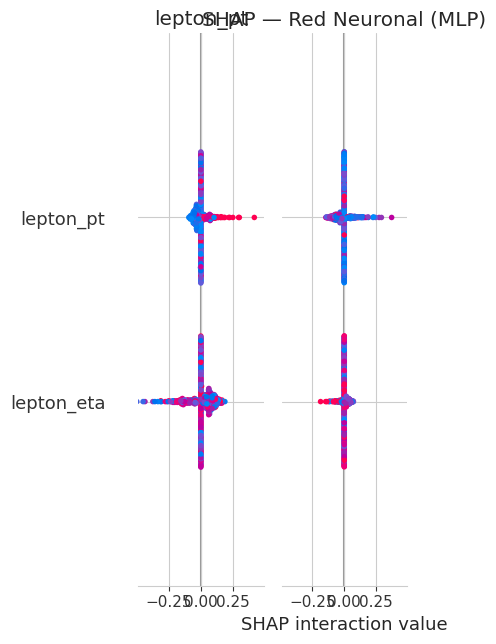

  Top 10 features SHAP:
  SKIP: only integer scalar arrays can be converted to a scalar index

--- XGBoost ---
  Tipo: XGBClassifier


  0%|          | 0/500 [00:00<?, ?it/s]

<Figure size 1000x600 with 0 Axes>

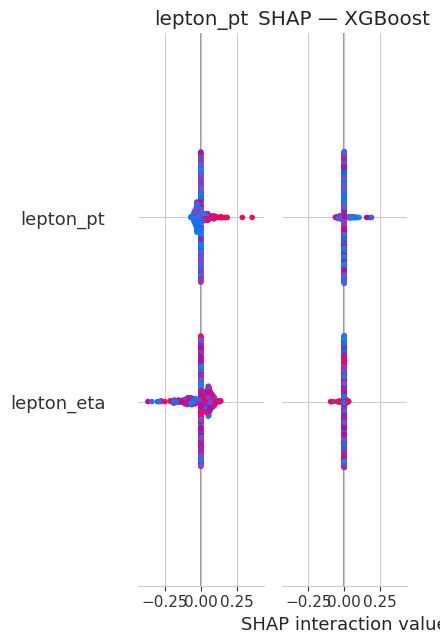

  Top 10 features SHAP:
  SKIP: only integer scalar arrays can be converted to a scalar index

SHAP completado.


In [4]:
# Celda 3 — SHAP: importancia multivariada de features (top-2 modelos)
# SHAP captura interacciones entre features. Complementa el d' univariado.
# Usamos submuestra de 5000 puntos de validación por eficiencia.

print("=" * 65)
print("ANÁLISIS SHAP — Importancia multivariada de features")
print("=" * 65)

N_SHAP = 5_000
idx_shap = np.random.default_rng(42).choice(len(X_val), N_SHAP, replace=False)
X_val_sample = X_val[idx_shap]

for nombre in top2_nombres:
    obj = top2_objetos[nombre]
    model = obj['model']
    scaler = obj['scaler']

    # Aplicar scaler
    try:
        X_sample_sc = scaler.transform(X_val_sample)
    except:
        X_sample_sc = X_val_sample

    print(f"\n--- {nombre} ---")
    print(f"  Tipo: {type(model).__name__}")

    try:
        background = shap.sample(X_sample_sc, 100, random_state=42)
        explainer = shap.KernelExplainer(model.predict_proba, background)
        shap_values = explainer.shap_values(X_sample_sc[:500])

        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_sample_sc[:500],
                          feature_names=FEATURES, show=False)
        plt.title(f"SHAP — {nombre}")
        plt.tight_layout()
        safe_fig = nombre.replace(" ", "_")[:30]
        plt.savefig(DRIVE_PATH + f"fig_shap_{safe_fig}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

        shap_importance = np.abs(shap_values).mean(axis=0)
        top_idx = np.argsort(shap_importance)[-10:][::-1]
        print(f"  Top 10 features SHAP:")
        for idx in top_idx:
            print(f"    {FEATURES[idx]:20s}: {shap_importance[idx]:.6f}")
    except Exception as e:
        print(f"  SKIP: {e}")

print("\nSHAP completado.")

ERROR ANALYSIS — ¿Dónde discrepan los top-2 modelos?

Desacuerdo entre 'Red Neuronal (MLP)' y 'XGBoost':
  Muestras en desacuerdo: 10249/75000 (13.7%)

  Cuando discrepan:
    Red Neuronal (MLP) acierta: 5177 (51%)
    XGBoost acierta: 5072 (49%)
    Ambos fallan:    0 (0%)

  Features con mayor diferencia (desacuerdo vs acuerdo):
    m_jj                : Δμ = 0.0923
    jet1_pt             : Δμ = 0.0700
    m_bb                : Δμ = 0.0590
    jet2_pt             : Δμ = 0.0457
    jet1_b_tag          : Δμ = 0.0396


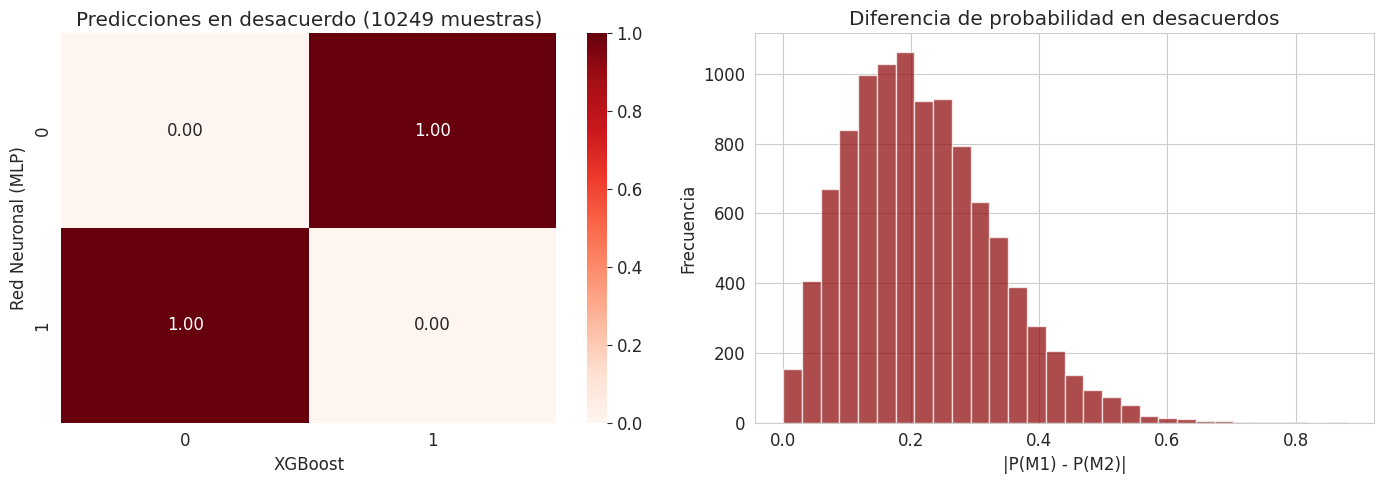


Error analysis completado.


In [5]:
# Celda 4 — Error Analysis: matriz de desacuerdo entre top-2 modelos
print("=" * 65)
print("ERROR ANALYSIS — ¿Dónde discrepan los top-2 modelos?")
print("=" * 65)

if len(top2_nombres) >= 2:
    m1_name, m2_name = top2_nombres[0], top2_nombres[1]
    m1 = top2_objetos[m1_name]
    m2 = top2_objetos[m2_name]

    try:
        X_test_m1 = m1['scaler'].transform(X_test)
    except:
        X_test_m1 = X_test
    try:
        X_test_m2 = m2['scaler'].transform(X_test)
    except:
        X_test_m2 = X_test

    pred_m1 = m1['model'].predict(X_test_m1)
    pred_m2 = m2['model'].predict(X_test_m2)
    prob_m1 = m1['model'].predict_proba(X_test_m1)[:, 1]
    prob_m2 = m2['model'].predict_proba(X_test_m2)[:, 1]

    disagree_mask = pred_m1 != pred_m2
    n_disagree = disagree_mask.sum()
    pct_disagree = 100 * n_disagree / len(y_test)

    print(f"\nDesacuerdo entre '{m1_name}' y '{m2_name}':")
    print(f"  Muestras en desacuerdo: {n_disagree}/{len(y_test)} ({pct_disagree:.1f}%)")

    m1_correct = (pred_m1 == y_test)
    m2_correct = (pred_m2 == y_test)
    m1_wins = (disagree_mask & m1_correct & ~m2_correct).sum()
    m2_wins = (disagree_mask & ~m1_correct & m2_correct).sum()
    both_wrong = (disagree_mask & ~m1_correct & ~m2_correct).sum()

    print(f"\n  Cuando discrepan:")
    print(f"    {m1_name} acierta: {m1_wins} ({100*m1_wins/n_disagree:.0f}%)")
    print(f"    {m2_name} acierta: {m2_wins} ({100*m2_wins/n_disagree:.0f}%)")
    print(f"    Ambos fallan:    {both_wrong} ({100*both_wrong/n_disagree:.0f}%)")

    if n_disagree > 100:
        X_disagree = X_test[disagree_mask]
        X_agree = X_test[~disagree_mask]
        diff_means = np.abs(X_disagree.mean(axis=0) - X_agree.mean(axis=0))
        top_diff_idx = np.argsort(diff_means)[-5:][::-1]
        print(f"\n  Features con mayor diferencia (desacuerdo vs acuerdo):")
        for idx in top_diff_idx:
            print(f"    {FEATURES[idx]:20s}: Δμ = {diff_means[idx]:.4f}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        cm_disagree = pd.crosstab(
            pd.Series(pred_m1[disagree_mask], name=m1_name[:20]),
            pd.Series(pred_m2[disagree_mask], name=m2_name[:20]),
            normalize='index'
        )
        sns.heatmap(cm_disagree, annot=True, fmt='.2f', cmap='Reds', ax=axes[0])
        axes[0].set_title(f'Predicciones en desacuerdo ({n_disagree} muestras)')
        conf_diff = np.abs(prob_m1[disagree_mask] - prob_m2[disagree_mask])
        axes[1].hist(conf_diff, bins=30, color='darkred', alpha=0.7)
        axes[1].set_xlabel('|P(M1) - P(M2)|')
        axes[1].set_ylabel('Frecuencia')
        axes[1].set_title('Diferencia de probabilidad en desacuerdos')
        plt.tight_layout()
        plt.savefig(DRIVE_PATH + "fig_error_analysis.png", dpi=150, bbox_inches="tight")
        plt.show()

print("\nError analysis completado.")

LEARNING CURVES — Diagnóstico bias/variance del mejor modelo
Submuestra para learning curves: (50000, 28)


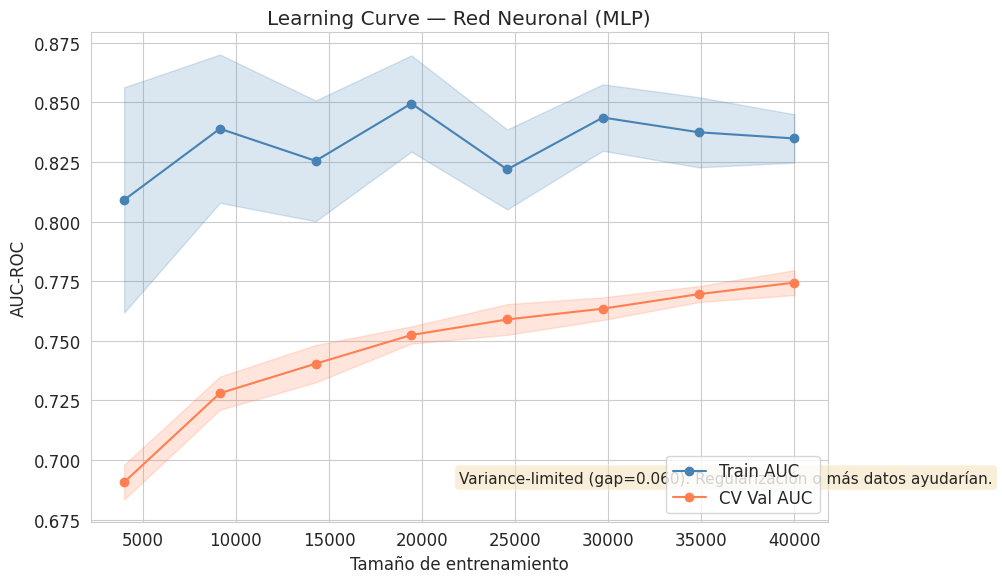


  Gap train-val final: 0.0605
  Diagnóstico: Variance-limited (gap=0.060). Regularización o más datos ayudarían.
  → Curva de validación sigue subiendo: más datos probablemente ayudarían.

Learning curves completado.


In [6]:
# Celda 5 — Learning Curves: diagnóstico bias vs variance (top-1 modelo)
print("=" * 65)
print("LEARNING CURVES — Diagnóstico bias/variance del mejor modelo")
print("=" * 65)

best_name = top2_nombres[0]
obj = top2_objetos[best_name]
model = obj['model']

try:
    X_train_sc = obj['scaler'].transform(X_train)
except:
    X_train_sc = X_train

# Submuestra para acelerar
N_LC = 50_000
idx_lc = np.random.default_rng(42).choice(len(X_train_sc), N_LC, replace=False)
X_lc = X_train_sc[idx_lc]
y_lc = y_train[idx_lc]
print(f"Submuestra para learning curves: {X_lc.shape}")

train_sizes = np.linspace(0.1, 1.0, 8)
train_sizes_abs, train_scores, val_scores = learning_curve(
    model, X_lc, y_lc,
    train_sizes=train_sizes,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_abs, train_mean - train_std,
                 train_mean + train_std, alpha=0.2, color='steelblue')
plt.fill_between(train_sizes_abs, val_mean - val_std,
                 val_mean + val_std, alpha=0.2, color='coral')
plt.plot(train_sizes_abs, train_mean, 'o-', color='steelblue', label='Train AUC')
plt.plot(train_sizes_abs, val_mean, 'o-', color='coral', label='CV Val AUC')
plt.xlabel('Tamaño de entrenamiento')
plt.ylabel('AUC-ROC')
plt.title(f'Learning Curve — {best_name}')

gap = train_mean[-1] - val_mean[-1]
if gap > 0.02:
    diag = f"Variance-limited (gap={gap:.3f}). Regularización o más datos ayudarían."
elif val_mean[-1] < 0.70:
    diag = f"Bias-limited (AUC val={val_mean[-1]:.3f}). Necesita más capacidad."
else:
    diag = f"Bien balanceado (gap={gap:.3f}, AUC={val_mean[-1]:.3f})."

plt.annotate(diag, xy=(0.5, 0.08), xycoords='axes fraction', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n  Gap train-val final: {gap:.4f}")
print(f"  Diagnóstico: {diag}")
if len(train_sizes_abs) >= 2 and val_mean[-1] > val_mean[-2] + 0.003:
    print("  → Curva de validación sigue subiendo: más datos probablemente ayudarían.")
else:
    print("  → Curva de validación estabilizada: datos adicionales tendrían poco impacto.")
print("\nLearning curves completado.")

In [7]:
# Celda 6 — McNemar's Test: significancia estadística entre top-2 modelos
print("=" * 65)
print("McNEMAR'S TEST — Significancia estadística de la diferencia")
print("=" * 65)

if len(top2_nombres) >= 2:
    from statsmodels.stats.contingency_tables import mcnemar

    m1_name, m2_name = top2_nombres[0], top2_nombres[1]
    m1 = top2_objetos[m1_name]
    m2 = top2_objetos[m2_name]

    try:
        X_test_m1 = m1['scaler'].transform(X_test)
    except:
        X_test_m1 = X_test
    try:
        X_test_m2 = m2['scaler'].transform(X_test)
    except:
        X_test_m2 = X_test

    pred_m1 = m1['model'].predict(X_test_m1)
    pred_m2 = m2['model'].predict(X_test_m2)

    m1_correct = (pred_m1 == y_test)
    m2_correct = (pred_m2 == y_test)

    both_ok  = (m1_correct & m2_correct).sum()
    m1_only  = (m1_correct & ~m2_correct).sum()
    m2_only  = (~m1_correct & m2_correct).sum()
    both_bad = (~m1_correct & ~m2_correct).sum()

    print(f"\n  Matriz de aciertos/fallos en test:")
    print(f"                   {m2_name[:25]} OK    {m2_name[:25]} FAIL")
    print(f"  {m1_name[:25]} OK    {both_ok:>6}      {m1_only:>6}")
    print(f"  {m1_name[:25]} FAIL  {m2_only:>6}      {both_bad:>6}")

    table = [[both_ok, m1_only], [m2_only, both_bad]]
    result = mcnemar(table, exact=False, correction=True)

    print(f"\n  Estadístico χ² (McNemar): {result.statistic:.2f}")
    print(f"  p-value: {result.pvalue:.4f}")
    if result.pvalue < 0.05:
        print(f"  → Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05)")
    else:
        print(f"  → Diferencia NO significativa (p ≥ 0.05)")

    # Comparar pares en top de la tabla
    if len(df_original) >= 3:
        print(f"\n  Comparación por pares (top modelos por AUC test):")
        top_aucs = df_original.sort_values("AUC Test", ascending=False)
        for i in range(min(3, len(top_aucs))):
            for j in range(i+1, min(4, len(top_aucs))):
                n1 = top_aucs.index[i]
                n2 = top_aucs.index[j]
                auc1 = float(top_aucs.loc[n1, "AUC Test"])
                auc2 = float(top_aucs.loc[n2, "AUC Test"])
                diff = auc1 - auc2
                sig = "✓" if abs(diff) > 0.01 else "~"
                print(f"    {n1[:25]} vs {n2[:25]}: ΔAUC = {diff:+.4f} {sig}")
else:
    print("Solo hay 1 modelo top. McNemar requiere ≥2 modelos.")

print("\nMcNemar's test completado.")

McNEMAR'S TEST — Significancia estadística de la diferencia

  Matriz de aciertos/fallos en test:
                   XGBoost OK    XGBoost FAIL
  Red Neuronal (MLP) OK     50748        5177
  Red Neuronal (MLP) FAIL    5072       14003

  Estadístico χ² (McNemar): 1.06
  p-value: 0.3043
  → Diferencia NO significativa (p ≥ 0.05)

  Comparación por pares (top modelos por AUC test):
    Red Neuronal (MLP) vs XGBoost: ΔAUC = +0.0000 ~
    Red Neuronal (MLP) vs CatBoost: ΔAUC = +0.0010 ~
    Red Neuronal (MLP) vs HistGradientBoosting: ΔAUC = +0.0010 ~
    XGBoost vs CatBoost: ΔAUC = +0.0010 ~
    XGBoost vs HistGradientBoosting: ΔAUC = +0.0010 ~
    CatBoost vs HistGradientBoosting: ΔAUC = +0.0000 ~

McNemar's test completado.
